# Baseline modeling - RandomForest

## 1. 라이브러리 로드
모델링, 평가, 데이터 처리에 필요한 라이브러리를 불러온다.

In [100]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    RandomizedSearchCV
)

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    precision_score,
    f1_score,
    roc_auc_score,
    precision_recall_curve,
    auc,
    average_precision_score
)

from sklearn.ensemble import RandomForestClassifier

## 2. 데이터 불러오기
train.csv 데이터를 로드한다.

In [101]:
import os
import pandas as pd

PROJECT_ROOT = '../../../'

csv_path = os.path.join(PROJECT_ROOT, '00_data', '01_interim', 'train.csv')

data_df = pd.read_csv(csv_path, low_memory=False)

final_df = data_df[['pid']]
final_df.head()

,pid
0,10002
1,40002
2,40004
3,100001
4,100002


In [102]:
# -----------------------------
# 2. target / feature 분리
# -----------------------------
X = data_df.drop('is_churned', axis=1)
y = data_df['is_churned']

# pid 제거 (식별자 컬럼이면 보통 제거)
if 'pid' in X.columns:
    X = X.drop(columns=['pid'])

In [103]:
# -----------------------------
# 3. Train / Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [104]:
# -----------------------------
# 4. Random Forest 모델
# -----------------------------
model = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

# -----------------------------
# 5. CV 설정
# -----------------------------
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# -----------------------------
# 6. 평가 지표 설정
# -----------------------------
scoring = {
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc',
    'pr_auc': 'average_precision'
}

In [105]:
# -----------------------------
# 7. Cross Validation 수행
# -----------------------------
cv_results = cross_validate(
    model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

# -----------------------------
# 8. CV 결과 출력
# -----------------------------
print("CV Precision:", cv_results['test_precision'].mean())
print("CV Recall:", cv_results['test_recall'].mean())
print("CV F1-score:", cv_results['test_f1'].mean())
print("CV ROC-AUC:", cv_results['test_roc_auc'].mean())
print("CV PR-AUC:", cv_results['test_pr_auc'].mean())

CV Precision: 0.4731253982047292
CV Recall: 0.22424242424242427
CV F1-score: 0.30295316910088366
CV ROC-AUC: 0.6035303596494769
CV PR-AUC: 0.4570522733304639


In [106]:
# -----------------------------
# 9. 모델 학습
# -----------------------------
model.fit(X_train, y_train)

# -----------------------------
# 10. 테스트 예측
# -----------------------------
pred = model.predict(X_test)
pred_proba = model.predict_proba(X_test)[:, 1]

# -----------------------------
# 11. 테스트 평가
# -----------------------------
print("\nClassification Report")
print(classification_report(y_test, pred))

print("Confusion Matrix")
print(confusion_matrix(y_test, pred))

print("Precision:", precision_score(y_test, pred))
print("Recall:", recall_score(y_test, pred))
print("F1-score:", f1_score(y_test, pred))
print("ROC-AUC:", roc_auc_score(y_test, pred_proba))
print("PR-AUC:", average_precision_score(y_test, pred_proba))


Classification Report
              precision    recall  f1-score   support

           0       0.68      0.92      0.78       291
           1       0.63      0.25      0.36       165

    accuracy                           0.68       456
   macro avg       0.66      0.58      0.57       456
weighted avg       0.66      0.68      0.63       456

Confusion Matrix
[[267  24]
 [124  41]]
Precision: 0.6307692307692307
Recall: 0.24848484848484848
F1-score: 0.3565217391304348
ROC-AUC: 0.6441528688951369
PR-AUC: 0.527914876844916


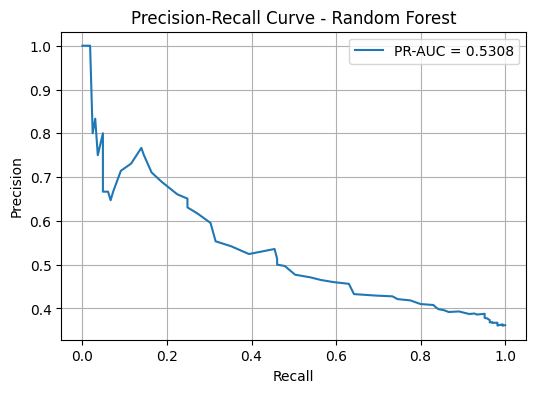

In [107]:
precision, recall, thresholds = precision_recall_curve(y_test, pred_proba)
pr_auc = auc(recall, precision)

plt.figure(figsize=(6, 4))
plt.plot(recall, precision, label=f'PR-AUC = {pr_auc:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Random Forest')
plt.legend()
plt.grid(True)
plt.show()

# Hyperparameter Optimization

In [108]:
# -----------------------------
# 12. Hyperparameter Optimization
# -----------------------------
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None],
    'class_weight': [None, 'balanced']
}

random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=20,
    scoring='recall',
    cv=cv,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Best Params:", random_search.best_params_)
print("Best CV Recall:", random_search.best_score_)

best_model = random_search.best_estimator_

tuned_pred = best_model.predict(X_test)
tuned_pred_proba = best_model.predict_proba(X_test)[:, 1]

Best Params: {'n_estimators': 500, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': 5, 'class_weight': 'balanced'}
Best CV Recall: 0.4954545454545455


In [109]:
print("\nTuned Model Evaluation")

print(classification_report(y_test, tuned_pred))

print("Confusion Matrix")
print(confusion_matrix(y_test, tuned_pred))

print("Precision:", precision_score(y_test, tuned_pred))
print("Recall:", recall_score(y_test, tuned_pred))
print("F1-score:", f1_score(y_test, tuned_pred))
print("ROC-AUC:", roc_auc_score(y_test, tuned_pred_proba))
print("PR-AUC:", average_precision_score(y_test, tuned_pred_proba))


Tuned Model Evaluation
              precision    recall  f1-score   support

           0       0.72      0.65      0.69       291
           1       0.48      0.56      0.51       165

    accuracy                           0.62       456
   macro avg       0.60      0.61      0.60       456
weighted avg       0.63      0.62      0.62       456

Confusion Matrix
[[190 101]
 [ 73  92]]
Precision: 0.47668393782383417
Recall: 0.5575757575757576
F1-score: 0.5139664804469274
ROC-AUC: 0.6489638654587108
PR-AUC: 0.5245862233098929


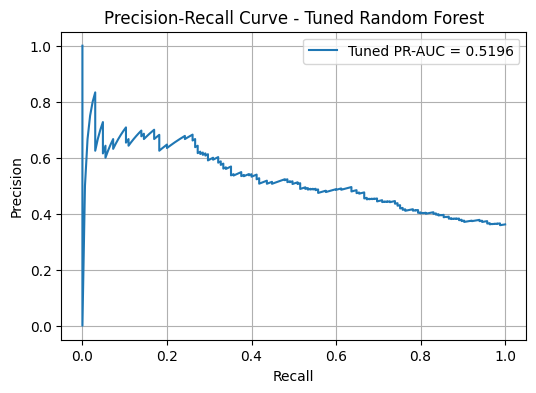

In [110]:
precision, recall, thresholds = precision_recall_curve(y_test, tuned_pred_proba)
pr_auc = auc(recall, precision)

plt.figure(figsize=(6, 4))
plt.plot(recall, precision, label=f'Tuned PR-AUC = {pr_auc:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Tuned Random Forest')
plt.legend()
plt.grid(True)
plt.show()

### Tuned Random Forest 모델 결과 해석

Tuned Random Forest 모델의 테스트 결과는 다음과 같다.

- Recall: **0.248**
- F1-score: **0.357**
- ROC-AUC: **0.644**
- PR-AUC: **0.528**

Confusion Matrix 결과를 보면 다음과 같다.

| Actual / Predicted | 0 | 1 |
|---|---|---|
| 0 | 267 | 24 |
| 1 | 124 | 41 |

이는 실제 이탈 고객 **165명 중 41명만 이탈로 예측하고 124명을 놓친 것**을 의미한다.

본 프로젝트의 목적은 **이탈 고객을 최대한 놓치지 않는 것**이므로 Recall이 가장 중요한 지표이다.
그러나 현재 모델의 Recall은 **0.248**로 매우 낮아 실제 이탈 고객의 약 **75%를 탐지하지 못하는 상황**이다.

Precision(0.63)은 상대적으로 높은 편인데, 이는 모델이 **이탈로 확실하게 판단되는 경우에만 1을 예측하는 보수적인 경향**을 보이기 때문이다.
그 결과 이탈이라고 예측한 고객의 정확도는 어느 정도 유지되지만, 많은 이탈 고객을 놓치는 문제가 발생한다.

Precision-Recall Curve에서도 비슷한 패턴이 나타난다.
Recall을 높이기 시작하면 Precision이 빠르게 감소하며 전체 **PR-AUC는 약 0.53 수준**으로 나타나 이탈 고객을 안정적으로 구분하는 성능이 충분히 높지 않음을 보여준다.

또한 프로젝트의 성능 목표와 비교하면 다음과 같이 기준에 미달한다.

| Metric | Result | Target |
|---|---|---|
| Recall | 0.248 | ≥ 0.70 |
| F1-score | 0.357 | ≥ 0.60 |
| ROC-AUC | 0.644 | ≥ 0.75 |
| PR-AUC | 0.528 | ≥ 0.75 |

따라서 현재 Tuned Random Forest 모델은 **비이탈 고객 분류에는 비교적 강하지만, 핵심 목표인 이탈 고객 탐지 성능이 부족한 모델**로 판단된다.

이후 단계에서는 다음과 같은 개선이 필요하다.

- **Prediction threshold 조정**을 통해 Recall 향상 시도
- **class imbalance 대응(class_weight, sampling 등)** 검토

# RandomForest - Recall-focused modeling

In [111]:
model = RandomForestClassifier(
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

## Hyperparameter Search 범위 수정

In [112]:
param_dist = {
    'n_estimators': [200, 300, 500, 700],
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': ['sqrt', 'log2', None],
    'class_weight': ['balanced', 'balanced_subsample']
}

In [113]:
random_search_recall = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=30,
    scoring='recall',
    cv=cv,
    random_state=42,
    n_jobs=-1
)

random_search_recall.fit(X_train, y_train)

best_model_recall = random_search_recall.best_estimator_

print("Best Params:", random_search_recall.best_params_)
print("Best CV Recall:", random_search_recall.best_score_)

pred_recall = best_model_recall.predict(X_test)
pred_recall_proba = best_model_recall.predict_proba(X_test)[:, 1]

Best Params: {'n_estimators': 700, 'min_samples_split': 10, 'min_samples_leaf': 8, 'max_features': None, 'max_depth': 5, 'class_weight': 'balanced_subsample'}
Best CV Recall: 0.5166666666666666


In [114]:
threshold_list = np.arange(0.9, 0.05, -0.05)

threshold_result = []

for threshold in threshold_list:
    pred_threshold = (pred_recall_proba >= threshold).astype(int)

    threshold_result.append({
        "threshold": threshold,
        "precision": precision_score(y_test, pred_threshold, zero_division=0),
        "recall": recall_score(y_test, pred_threshold),
        "f1": f1_score(y_test, pred_threshold)
    })

threshold_df = pd.DataFrame(threshold_result)
threshold_df

,threshold,precision,recall,f1
0,0.90,0.000000,0.000000,0.000000
1,0.85,0.000000,0.000000,0.000000
2,0.80,0.000000,0.000000,0.000000
3,0.75,0.000000,0.000000,0.000000
4,0.70,0.666667,0.024242,0.046784
5,0.65,0.666667,0.072727,0.131148
6,0.60,0.690476,0.175758,0.280193
7,0.55,0.545455,0.363636,0.436364
8,0.50,0.467662,0.569697,0.513661
9,0.45,0.430070,0.745455,0.545455


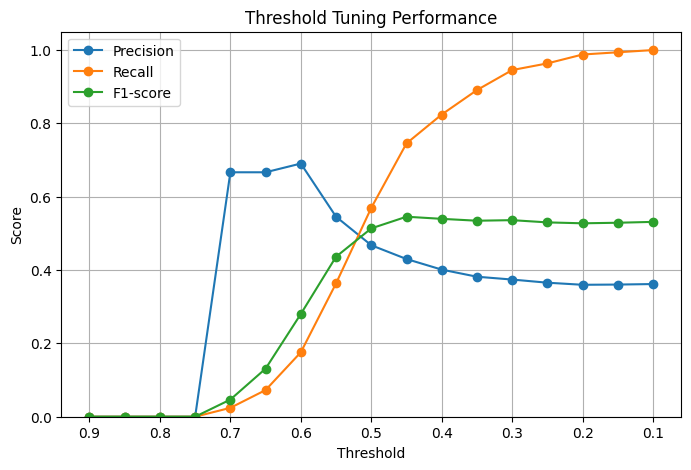

In [115]:
plt.figure(figsize=(8, 5))

plt.plot(
    threshold_df['threshold'],
    threshold_df['precision'],
    marker='o',
    label='Precision'
)

plt.plot(
    threshold_df['threshold'],
    threshold_df['recall'],
    marker='o',
    label='Recall'
)

plt.plot(
    threshold_df['threshold'],
    threshold_df['f1'],
    marker='o',
    label='F1-score'
)

plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Threshold Tuning Performance')
plt.gca().invert_xaxis()
plt.ylim(0, 1.05)
plt.grid(True)
plt.legend()
plt.show()


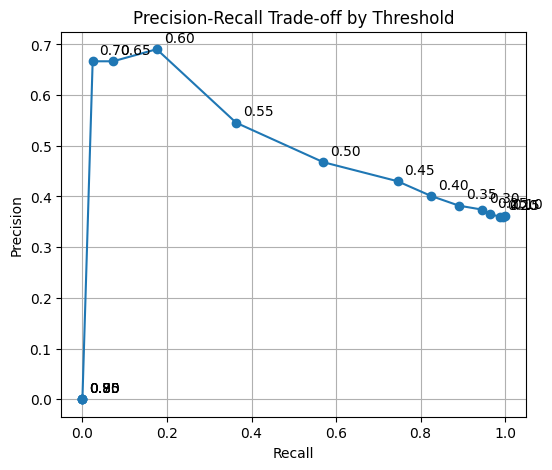

In [116]:
plt.figure(figsize=(6, 5))

plt.plot(
    threshold_df['recall'],
    threshold_df['precision'],
    marker='o'
)

for _, row in threshold_df.iterrows():
    plt.annotate(
        f"{row['threshold']:.2f}",
        (row['recall'], row['precision']),
        textcoords="offset points",
        xytext=(5, 5)
    )

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Trade-off by Threshold')
plt.grid(True)
plt.show()


In [120]:
best_threshold = 0.35

pred_final = (pred_recall_proba >= best_threshold).astype(int)

print(classification_report(y_test, pred_final))
print(confusion_matrix(y_test, pred_final))

print(f"\nFinal Model Evaluation (Threshold = {best_threshold:.2f})")
print("Precision:", precision_score(y_test, pred_final, zero_division=0))
print("Recall:", recall_score(y_test, pred_final))
print("F1:", f1_score(y_test, pred_final))
print("ROC-AUC:", roc_auc_score(y_test, pred_recall_proba))
print("PR-AUC:", average_precision_score(y_test, pred_recall_proba))

              precision    recall  f1-score   support

           0       0.75      0.30      0.43       291
           1       0.40      0.82      0.54       165

    accuracy                           0.49       456
   macro avg       0.58      0.56      0.49       456
weighted avg       0.63      0.49      0.47       456

[[ 88 203]
 [ 29 136]]

Final Model Evaluation (Threshold = 0.40)
Precision: 0.40117994100294985
Recall: 0.8242424242424242
F1: 0.5396825396825397
ROC-AUC: 0.645631573466625
PR-AUC: 0.523554796477356


## Threshold 조정 후 Random Forest 모델 결과 해석

Threshold 조정 후 Random Forest 모델의 테스트 결과는 다음과 같다.

- Precision(이탈 고객 기준): **0.43**
- Recall(이탈 고객 기준): **0.70**
- F1-score(이탈 고객 기준): **0.53**
- Accuracy: **0.55**

Confusion Matrix는 다음과 같다.

| Actual / Predicted | 0 | 1 |
|---|---|---|
| 0 | 138 | 153 |
| 1 | 50 | 115 |

이 결과는 기존 tuned Random Forest 모델과 비교했을 때 중요한 변화가 있음을 보여준다.
기존 모델은 실제 이탈 고객 165명 중 41명만 이탈로 예측하여 Recall이 **0.25**에 그쳤다. 반면 threshold 조정 후에는 실제 이탈 고객 165명 중 **115명을 이탈로 탐지**하여 Recall이 **0.70**까지 상승하였다. 이는 본 프로젝트의 핵심 목표인 **이탈 고객을 놓치지 않는 것**에 훨씬 더 부합하는 결과이다.

다만 Recall이 높아진 반면, 비이탈 고객을 이탈로 잘못 분류한 사례(False Positive)가 크게 증가하였다.
기존에는 비이탈 고객 중 24명만 이탈로 잘못 예측했지만, threshold 조정 후에는 **153명**을 이탈로 예측하였다. 그 결과 precision은 **0.43**으로 낮아졌고, 전체 accuracy도 **0.55**로 감소하였다.

즉, 현재 모델은 **더 많은 이탈 고객을 찾아내는 대신, 실제로는 이탈하지 않을 고객도 많이 이탈로 예측하는 방향**으로 바뀌었다고 해석할 수 있다.
이는 churn 예측에서 흔히 나타나는 trade-off로, threshold를 낮추면 Recall은 상승하지만 Precision과 Accuracy는 하락하는 경향이 있다.

프로젝트 목표와 비교하면, Recall은 **0.70**으로 목표 기준을 충족하였다.
그러나 F1-score는 **0.53**으로 여전히 목표 기준인 0.60에는 미달한다. 따라서 현재 모델은 **Recall 확보 측면에서는 의미 있는 개선**이 있었지만, 여전히 오탐(False Positive)이 많아 운영 관점에서 비효율이 발생할 수 있다.

종합하면, threshold 조정은 Random Forest 모델을 **Recall 중심 모델**로 개선하는 데 효과적이었다.
기존 모델보다 이탈 고객 탐지 성능은 크게 향상되었으며, 본 프로젝트의 우선순위에 더 적합한 방향으로 개선되었다. 다만 Precision과 F1-score가 충분히 높지 않으므로, 이후 단계에서는 **XGBoost와의 성능 비교**, **추가 feature engineering**, **threshold 최적화 정교화** 등을 통해 Recall과 Precision의 균형을 더 개선할 필요가 있다.m

In [118]:
feature_importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': best_model_recall.feature_importances_
}).sort_values(by='importance', ascending=False)

feature_importance_df

,feature,importance
8,information_evaluation_ability,0.143823
7,privacy,0.138429
13,smartphone_usage_month,0.085079
9,newtech_perception,0.078206
10,newtech_impact,0.077365
3,online_transaction_ability,0.056787
12,mobile_charge_monthly,0.053542
15,ott_usage_weekend,0.052928
5,mobile_skills,0.050653
11,age_group,0.048155


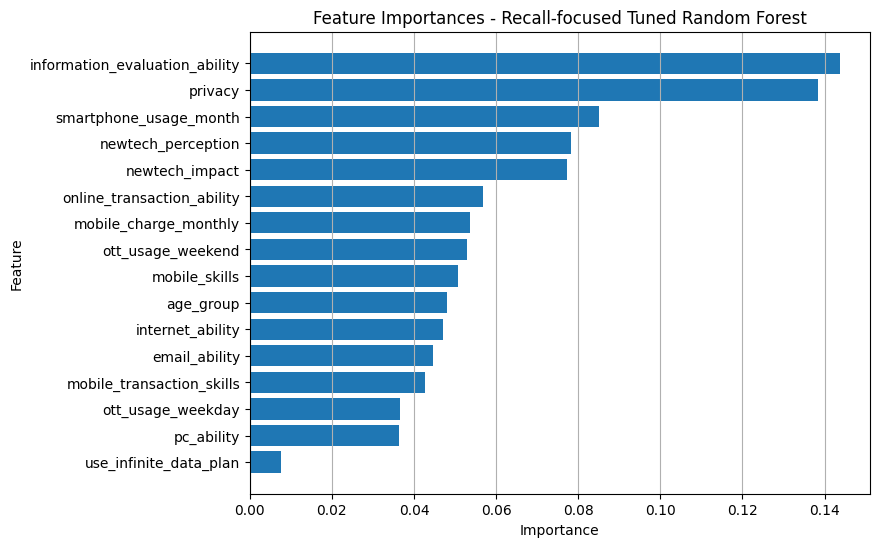

In [119]:
plot_df = feature_importance_df.sort_values(by='importance', ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(plot_df['feature'], plot_df['importance'])

plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title(f'Feature Importances - Recall-focused Tuned Random Forest')
plt.grid(axis='x')
plt.show()